# TITANIC PASSENGER SURVIVAL FORECAST: The Goal is to Predict whether a passenger survived the Titanic disaster (Survived = 1) or did not survive (Survived = 0) using passenger information.

In [1]:
# CAPSTONE PROJECT: Machine Learning Models for a Titanic Passenger Survival Forecast
# Dataset: TITANIC PASSENGER SURVIVAL Prediction dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:

# STAGE 1: LOAD AND CLEAN
# ------------------------------------------------------------
df = pd.read_csv("titanic.csv")

print("Shape:", df.shape)
print(df.info())


Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [3]:
# Check missing values
print(df.isnull().sum())
# print("\nMissing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicate rows: 0


In [4]:
# Drop duplicates and drop the column with missing values(Cabin), drop Name and Ticket column not useful for the prediction
df = df.drop_duplicates()
df = df.drop(columns=["Cabin", "Name", "Ticket"])

In [5]:
# Fill missing categorical values with the most common value (mode)
for col in ["Embarked"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
# Fill missing numerical values that is Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

In [7]:
# Check missing values after treatment
print("\nMissing values after treatment:")
print(df.isnull().sum())


Missing values after treatment:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [8]:
df.shape
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 62.8 KB
None


In [9]:
# checking the median number used for age and the categorical mode used for embarked
print("Age median:", df["Age"].median())
print("Most common Embarked:", df["Embarked"].mode()[0])

Age median: 28.0
Most common Embarked: S


In [10]:
print(df[["Age", "Embarked"]].head(20))

     Age Embarked
0   22.0        S
1   38.0        C
2   26.0        S
3   35.0        S
4   35.0        S
5   28.0        Q
6   54.0        S
7    2.0        S
8   27.0        S
9   14.0        C
10   4.0        S
11  58.0        S
12  20.0        S
13  39.0        S
14  14.0        S
15  55.0        S
16   2.0        Q
17  28.0        S
18  31.0        S
19  28.0        C


In [11]:
# STAGE 2: EXPLORE AND DESCRIBE
# ------------------------------------------------------------
print(df.describe())

print("Average Age:", round(df["Age"].mean(), 2))
print("Median Age:", round(df["Age"].median(), 2))

print("Average Fare:", round(df["Fare"].mean(), 2))
print("Median Fare:", round(df["Fare"].median(), 2))
print("Survival Counts:")
print(df["Survived"].value_counts())

survival_percentage = (
    df["Survived"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Survival Percentage:")
print(survival_percentage)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
Average Age: 29.36
Median Age: 28.0
Average Fare: 32.2
Median Fare: 14.45
Surviva

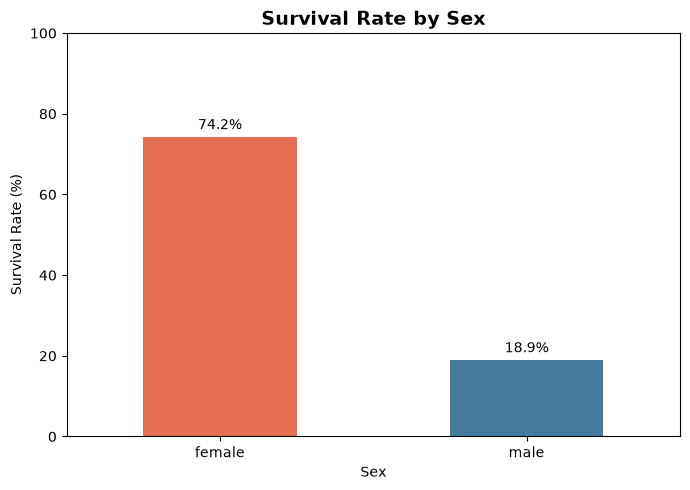

In [12]:
# STAGE 3: VISUALIZATION
# ------------------------------------------------------------
# Chart 1 — Survival by Sex

survival_by_sex = (df.groupby("Sex")["Survived"].mean().mul(100))

plt.figure(figsize=(7, 5))

ax = survival_by_sex.plot(kind="bar", color=["#E76F51", "#457B9D"])

plt.title("Survival Rate by Sex", fontsize=14, fontweight="bold")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(survival_by_sex):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.savefig("survival_by_sex.png")
plt.tight_layout()
plt.show()

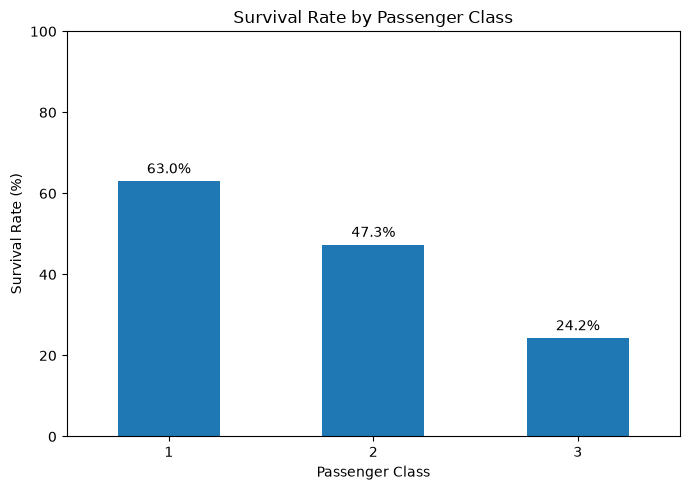

In [13]:
# Chart 2 — Survival by Class

survival_by_class = (
    df.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))

ax = survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(survival_by_class):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")
    
plt.savefig("survival_by_class.png")
plt.tight_layout()
plt.show()

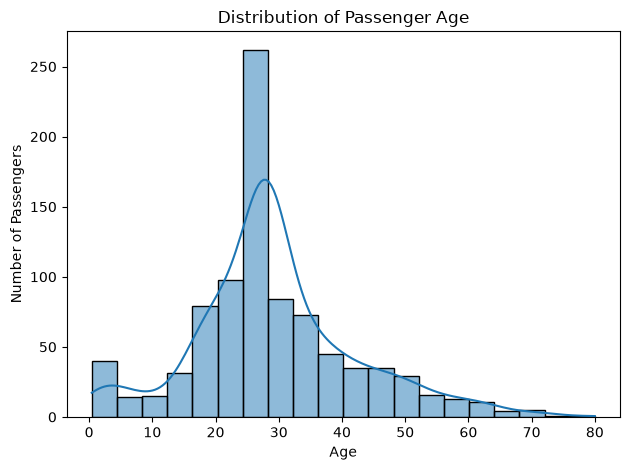

In [14]:
plt.Figure()
sns.histplot(df["Age"], kde=True, bins=20, edgecolor="black")

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.savefig("Age_Distribution.png")
plt.tight_layout()
plt.show()

# The histogram with the KDE curve shows the distribution of passenger ages. The distribution is slightly right-skewed, 
# with the mean age of 29.36 years being slightly higher than the median age of 28 years. The KDE curve provides a smoother representation of the distribution
# and shows that most passengers were concentrated within the younger and middle-age ranges.

In [15]:
# STAGE 4: PREPARE FOR MODELING
# ------------------------------------------------------------
# Drop identifier/text columns with no predictive value for this baseline

X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]

y = df["Survived"]

# Encode categorical variables
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

# Train/test split USING 80% For Training and 20% for Testing

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42, stratify=y) 
# The stratify=y helps maintain a similar survival proportion in both datasets.

# Scale the numerical variables
# i used Logistic Regression, so scaling is appropriate
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
# STAGE 5: TRAIN A MODEL
# ------------------------------------------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

Model Accuracy: 80.45%
Confusion Matrix:
[[98 12]
 [23 46]]


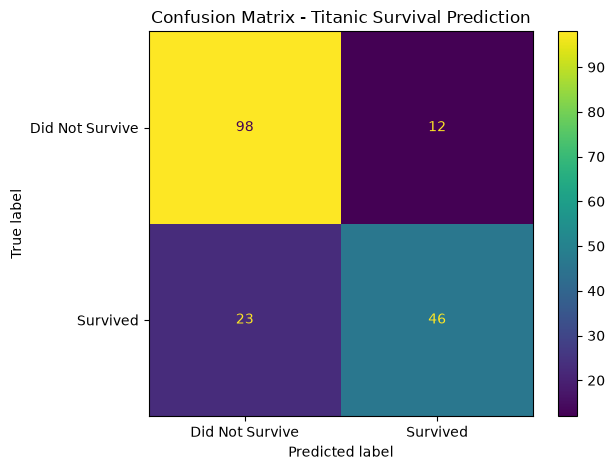

In [17]:
# STAGE 6: EVALUATE
# ------------------------------------------------------------

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()

plt.title("Confusion Matrix - Titanic Survival Prediction")
plt.savefig("Confusion Matrix - Titanic_survival.png")
plt.tight_layout()
plt.show()



The Logistic Regression model achieved an accuracy of 80.45% on the test dataset, indicating that it correctly classified approximately four out of every five passengers. The confusion matrix showed 98 true negatives and 46 true positives, meaning that these passengers were correctly classified according to their actual survival status. The model produced 12 false positives, where passengers were predicted to survive but did not, and 23 false negatives, where passengers were predicted not to survive but actually survived. Therefore, although accuracy provides a useful overall measure of performance, the confusion matrix provides additional insight into the types of errors made by the model. 

# STAGE 7: SUMMARIZE FINDINGS
# ------------------------------------------------------------
This project used the Titanic passenger dataset to develop a classification model for predicting whether a passenger survived or did not survive the disaster. The dataset contained 891 passenger records, and missing values in the Age and Embarked columns were handled using the median and mode respectively, while the Cabin column was excluded because of its high proportion of missing values. Exploratory analysis showed that 38.38% of passengers survived, with an average age of 29.36 years and an average fare of 32.20. Survival varied considerably by sex, with females having a survival rate of 74.20% compared with only 18.89% for males. Survival also differed by passenger class, with first-class passengers recording a 62.96% survival rate compared with 47.28% for second class and 24.24% for third class. Categorical variables were encoded, the data was divided into training and testing sets, and numerical features were standardized before modeling. A Logistic Regression classification model was trained to predict passenger survival and achieved an accuracy of 80.45% on the test dataset. The confusion matrix showed 98 true negatives, 46 true positives, 12 false positives, and 23 false negatives, while the model achieved a 67% recall for passengers who actually survived. Overall, the analysis shows that passenger characteristics such as sex, passenger class, age, and fare contain useful information for predicting survival, although these relationships represent associations rather than proof of causation.